# Informe 3 — Modelos de Regresión
---
## VidaCare Peru
**Proyecto Grupal — Inteligencia Artificial — UNMSM **

### Integrantes del grupo

| N° | Apellidos y Nombres | 
|----|-------------------|
| 1 | Nuñez Cardenas Ivan Joaquin |
| 2 | Guevara Chavez Luis Rodrigo |
| 3 | Bejar Mallma Harian Aaron |
| 4 | Arancivia Salas Christian Gabriel |
| 5 | Rojas Rojas Max Fernando |

**Objetivo del informe:** Identificar qué factores explican el gasto total anual de un paciente
mediante modelos de regresión supervisada, y seleccionar el modelo con mejor capacidad predictiva
para apoyar la toma de decisiones del equipo de marketing de VidaCare.

**Variable objetivo (target):** `gasto_total_anual` — Gasto total anual del paciente en soles (0–50,000).

**Técnicas aplicadas:** Regresión Lineal Simple, Múltiple, Polinómica, Ridge, Lasso y Gradient Boosting.

### Dataset

- **Empresa:** VidaCare Peru — Healthtech peruana que conecta pacientes con especialistas a traves de telemedicina y atencion presencial.
- **Archivo:** `pacientes_vidacare.csv`
- **Filas:** 1500 pacientes
- **Variables:** 12 (4 numericas para clustering, 1 categorica, 1 binaria objetivo, resto complementarias)
- **Semilla:** 42 (reproducible)

---

In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")
np.random.seed(2026)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Cargar dataset
df = pd.read_csv("pacientes_vidacare.csv")
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: (1500, 12)

Primeras 5 filas:


,id_paciente,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,tipo_plan,canal_atencion,gasto_total_anual,abandono,num_condiciones_cronicas
0,P0001,49,4156,14.0,215.00,10.0,91.0,Premium,Telemedicina,2833.46,0,1
1,P0002,29,2927,16.0,198.78,53.0,51.0,Premium,Presencial,3061.50,1,0
2,P0003,56,5522,3.0,169.85,28.0,100.0,Preventivo,Presencial,531.79,0,1
3,P0004,59,5205,16.0,124.45,55.0,54.0,Premium,Telemedicina,3187.92,1,1
4,P0005,18,2474,15.0,199.16,29.0,47.0,Premium,Presencial,2914.18,0,0


In [3]:
# Información general y valores nulos
print("=== Información del DataFrame ===")
df.info()
print("\n=== Valores nulos por columna ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal nulos: {df.isnull().sum().sum()} ({df.isnull().sum().sum()/len(df)*100:.2f}%)")

=== Información del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_paciente               1500 non-null   object 
 1   edad                      1500 non-null   int64  
 2   ingreso_mensual           1500 non-null   int64  
 3   frecuencia_citas          1440 non-null   float64
 4   gasto_promedio_cita       1440 non-null   float64
 5   antiguedad_meses          1440 non-null   float64
 6   recencia_dias             1440 non-null   float64
 7   tipo_plan                 1440 non-null   object 
 8   canal_atencion            1500 non-null   object 
 9   gasto_total_anual         1500 non-null   float64
 10  abandono                  1500 non-null   int64  
 11  num_condiciones_cronicas  1500 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 140.8+ KB

=== Valores nulos por co

In [4]:
# Estadísticas descriptivas
df.describe().round(2)

,edad,ingreso_mensual,frecuencia_citas,gasto_promedio_cita,antiguedad_meses,recencia_dias,gasto_total_anual,abandono,num_condiciones_cronicas
count,1500.00,1500.00,1440.00,1440.00,1440.00,1440.00,1500.00,1500.00,1500.00
mean,44.45,4151.05,8.78,150.32,30.59,63.74,1382.64,0.33,1.08
std,14.36,999.90,4.79,42.32,17.46,24.43,1088.96,0.47,0.90
min,18.00,1360.00,0.00,30.00,1.00,1.00,0.00,0.00,0.00
25%,34.00,3451.00,5.00,120.47,15.00,47.00,598.20,0.00,0.00
50%,45.00,4120.50,8.00,144.04,31.00,64.00,1020.56,0.00,1.00
75%,54.00,4814.75,12.00,174.69,46.00,81.00,1833.70,1.00,2.00
max,85.00,7648.00,29.00,282.78,60.00,137.00,7086.39,1.00,5.00


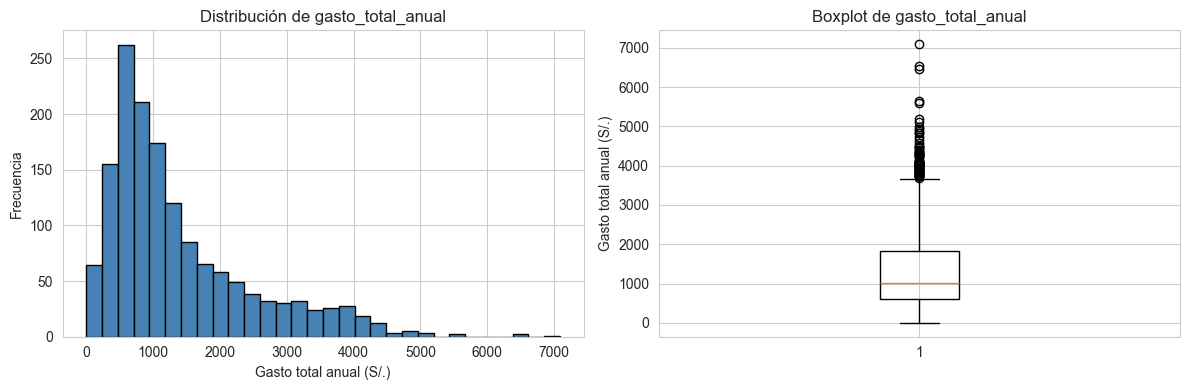

Media:   S/1,382.64
Mediana: S/1,020.56
Std:     S/1,088.96
Mín:     S/    0.00
Máx:     S/7,086.39


In [5]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["gasto_total_anual"], bins=30, edgecolor="black", color="steelblue")
axes[0].set_title("Distribución de gasto_total_anual")
axes[0].set_xlabel("Gasto total anual (S/.)")
axes[0].set_ylabel("Frecuencia")
axes[1].boxplot(df["gasto_total_anual"])
axes[1].set_title("Boxplot de gasto_total_anual")
axes[1].set_ylabel("Gasto total anual (S/.)")
plt.tight_layout()
plt.show()
print(f"Media:   S/{df['gasto_total_anual'].mean():>8,.2f}")
print(f"Mediana: S/{df['gasto_total_anual'].median():>8,.2f}")
print(f"Std:     S/{df['gasto_total_anual'].std():>8,.2f}")
print(f"Mín:     S/{df['gasto_total_anual'].min():>8,.2f}")
print(f"Máx:     S/{df['gasto_total_anual'].max():>8,.2f}")

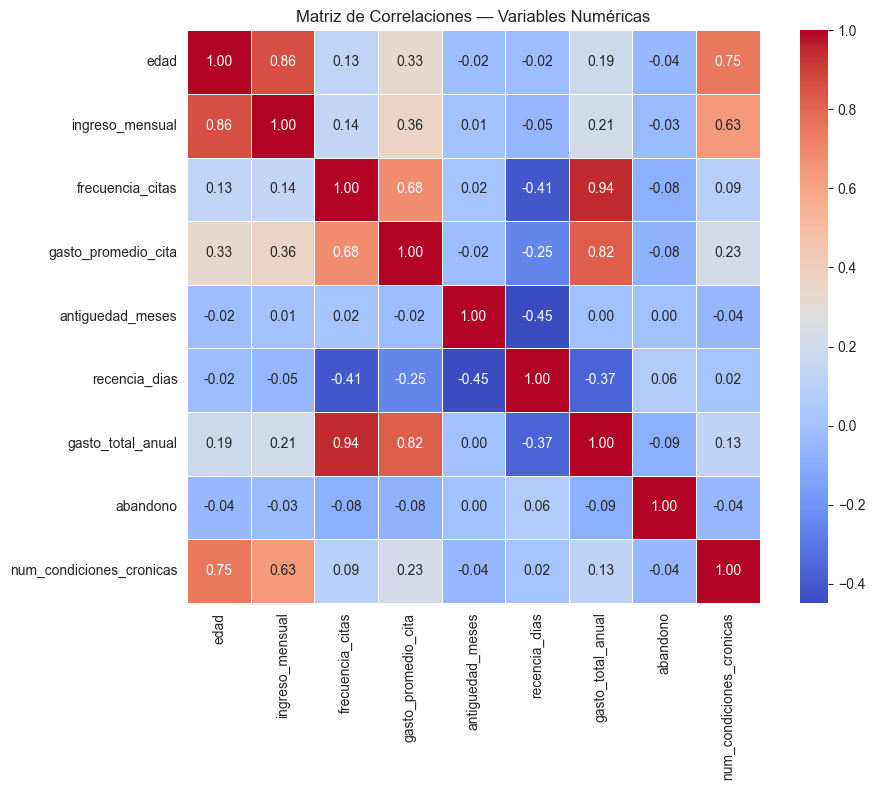


Correlación con gasto_total_anual:
gasto_total_anual           1.0000
frecuencia_citas            0.9439
gasto_promedio_cita         0.8192
ingreso_mensual             0.2097
edad                        0.1859
num_condiciones_cronicas    0.1261
antiguedad_meses            0.0001
abandono                   -0.0909
recencia_dias              -0.3669
Name: gasto_total_anual, dtype: float64


In [6]:
# Mapa de calor de correlaciones
num_cols = df.select_dtypes(include="number").drop(columns=["id_paciente"], errors="ignore")
corr = num_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Matriz de Correlaciones — Variables Numéricas")
plt.tight_layout()
plt.show()
print("\nCorrelación con gasto_total_anual:")
print(corr["gasto_total_anual"].sort_values(ascending=False).round(4))

Top 3 variables correlacionadas con gasto_total_anual: ['frecuencia_citas', 'gasto_promedio_cita', 'ingreso_mensual']


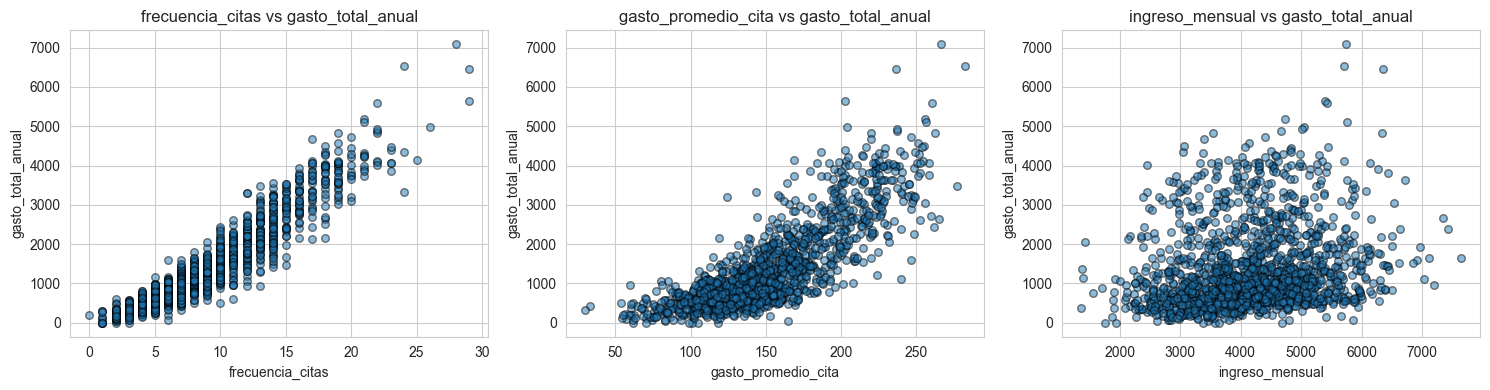

In [7]:
# Scatterplots de las 3 variables más correlacionadas
top_vars = corr["gasto_total_anual"].drop("gasto_total_anual").nlargest(3).index.tolist()
print("Top 3 variables correlacionadas con gasto_total_anual:", top_vars)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var in zip(axes, top_vars):
    ax.scatter(df[var], df["gasto_total_anual"], alpha=0.5, edgecolors="k", s=30)
    ax.set_xlabel(var)
    ax.set_ylabel("gasto_total_anual")
    ax.set_title(f"{var} vs gasto_total_anual")
plt.tight_layout()
plt.show()

In [8]:
# Separar features y target
target = "gasto_total_anual"
y = df[target].values

num_features = ["edad", "ingreso_mensual", "frecuencia_citas",
               "gasto_promedio_cita", "antiguedad_meses", "recencia_dias",
               "num_condiciones_cronicas"]
cat_features = ["tipo_plan", "canal_atencion"]

X = df[num_features + cat_features]
print(f"Features numéricas ({len(num_features)}): {num_features}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")
print(f"\nShape X: {X.shape}, shape y: {y.shape}")

Features numéricas (7): ['edad', 'ingreso_mensual', 'frecuencia_citas', 'gasto_promedio_cita', 'antiguedad_meses', 'recencia_dias', 'num_condiciones_cronicas']
Features categóricas (2): ['tipo_plan', 'canal_atencion']

Shape X: (1500, 9), shape y: (1500,)


In [9]:
# Pipeline de preprocesamiento
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])
print("Pipeline de preprocesamiento creado.")

Pipeline de preprocesamiento creado.


In [10]:
# División train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2026)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 1200 muestras
Prueba:        300 muestras


In [11]:
# Aplicar preprocesamiento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = cat_encoder.get_feature_names_out(cat_features).tolist()
feature_names = num_features + cat_feature_names

print(f"Features finales ({len(feature_names)}): {feature_names}")
print(f"\nShape X_train_processed: {X_train_processed.shape}")
print(f"Shape X_test_processed:  {X_test_processed.shape}")

Features finales (10): ['edad', 'ingreso_mensual', 'frecuencia_citas', 'gasto_promedio_cita', 'antiguedad_meses', 'recencia_dias', 'num_condiciones_cronicas', 'tipo_plan_Premium', 'tipo_plan_Preventivo', 'canal_atencion_Telemedicina']

Shape X_train_processed: (1200, 10)
Shape X_test_processed:  (300, 10)


## Modelo 1: Regresión Lineal Simple

Usaremos la variable más correlacionada con `gasto_total_anual` como predictor único.

In [12]:
# Regresión Lineal Simple (mejor predictor)
best_feature = top_vars[0]
idx_best = num_features.index(best_feature)

X_train_simple = X_train_processed[:, idx_best].reshape(-1, 1)
X_test_simple = X_test_processed[:, idx_best].reshape(-1, 1)

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)
y_pred_simple = simple_lr.predict(X_test_simple)

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("=== Regresión Lineal Simple ===")
print(f"  Predictor: {best_feature}")
print(f"  MSE : {mse_simple:>10,.2f}")
print(f"  RMSE: {rmse_simple:>10,.2f}")
print(f"  MAE : {mae_simple:>10,.2f}")
print(f"  R²  : {r2_simple:>10.4f}")

=== Regresión Lineal Simple ===
  Predictor: frecuencia_citas
  MSE : 149,809.72
  RMSE:     387.05
  MAE :     280.54
  R²  :     0.8694


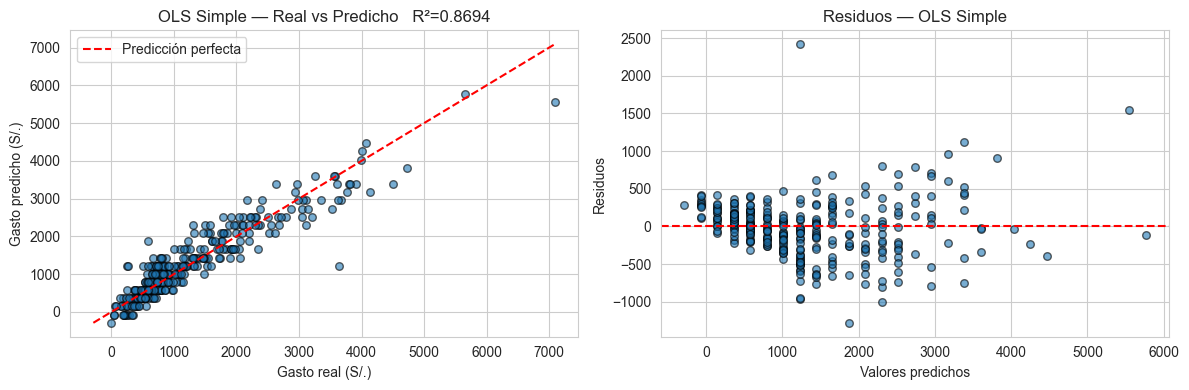

In [13]:
# Gráfico OLS Simple
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred_simple, alpha=0.6, edgecolors="k", s=30)
lims = [min(y_test.min(), y_pred_simple.min()), max(y_test.max(), y_pred_simple.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Gasto real (S/.)")
axes[0].set_ylabel("Gasto predicho (S/.)")
axes[0].set_title(f"OLS Simple — Real vs Predicho   R²={r2_simple:.4f}")
axes[0].legend()
residuos_simple = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuos_simple, alpha=0.6, edgecolors="k", s=30)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Valores predichos")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos — OLS Simple")
plt.tight_layout()
plt.show()

## Modelo 2: Regresión Lineal Múltiple (OLS)

In [14]:
# Regresión Lineal Múltiple
ols = LinearRegression()
ols.fit(X_train_processed, y_train)
y_pred_ols = ols.predict(X_test_processed)

mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("=== Regresión Lineal Múltiple (OLS) ===")
print(f"  MSE : {mse_ols:>10,.2f}")
print(f"  RMSE: {rmse_ols:>10,.2f}")
print(f"  MAE : {mae_ols:>10,.2f}")
print(f"  R²  : {r2_ols:>10.4f}")

=== Regresión Lineal Múltiple (OLS) ===
  MSE :  70,201.76
  RMSE:     264.96
  MAE :     182.71
  R²  :     0.9388


In [15]:
# Coeficientes OLS
coef_ols = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": ols.coef_
}).sort_values("Coeficiente", ascending=False)
print(f"Intercepto (β₀): {ols.intercept_:,.2f}")
print(coef_ols.to_string(index=False))

Intercepto (β₀): 1,315.99
                   Variable  Coeficiente
           frecuencia_citas   686.931311
          tipo_plan_Premium   493.136229
        gasto_promedio_cita   284.348874
            ingreso_mensual    39.506136
   num_condiciones_cronicas     4.560549
canal_atencion_Telemedicina     3.961260
                       edad   -14.251911
           antiguedad_meses   -15.346125
              recencia_dias   -16.272125
       tipo_plan_Preventivo   -33.572626


## Modelo 3: Regresión Polinómica

In [16]:
# Pipeline Polinómica (grado 2)
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("reg", LinearRegression())
])
poly_pipeline.fit(X_train_processed, y_train)
y_pred_poly = poly_pipeline.predict(X_test_processed)

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Regresión Polinómica (grado 2) ===")
print(f"  MSE : {mse_poly:>10,.2f}")
print(f"  RMSE: {rmse_poly:>10,.2f}")
print(f"  MAE : {mae_poly:>10,.2f}")
print(f"  R²  : {r2_poly:>10.4f}")
print(f"  Núm. características: {poly_pipeline.named_steps['poly'].n_output_features_}")

=== Regresión Polinómica (grado 2) ===
  MSE :  41,340.92
  RMSE:     203.32
  MAE :     136.33
  R²  :     0.9640
  Núm. características: 65


In [17]:
# Comparar grados 1, 2 y 3
resultados_poly = {}
for grado in [1, 2, 3]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("reg", LinearRegression())
    ])
    pipe.fit(X_train_processed, y_train)
    yp = pipe.predict(X_test_processed)
    resultados_poly[f"Polinómica d{grado}"] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, yp)),
        "R2": r2_score(y_test, yp),
        "n_features": pipe.named_steps["poly"].n_output_features_
    }
print(f"{'Modelo':<20} {'RMSE':>12} {'R²':>10} {'# Features':>12}")
print("-" * 58)
for nombre, m in resultados_poly.items():
    print(f"{nombre:<20} {m['RMSE']:>12,.2f} {m['R2']:>10.4f} {m['n_features']:>12}")

Modelo                       RMSE         R²   # Features
----------------------------------------------------------
Polinómica d1              264.96     0.9388           10
Polinómica d2              203.32     0.9640           65
Polinómica d3              241.76     0.9491          285


## Modelo 4: Ridge (Regularización L2)

In [18]:
# Ridge con RidgeCV
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_processed, y_train)
y_pred_ridge = ridge_cv.predict(X_test_processed)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("=== Ridge (L2) ===")
print(f"  Mejor alpha: {ridge_cv.alpha_}")
print(f"  MSE : {mse_ridge:>10,.2f}")
print(f"  RMSE: {rmse_ridge:>10,.2f}")
print(f"  MAE : {mae_ridge:>10,.2f}")
print(f"  R²  : {r2_ridge:>10.4f}")

=== Ridge (L2) ===
  Mejor alpha: 1.0
  MSE :  70,145.21
  RMSE:     264.85
  MAE :     182.71
  R²  :     0.9389


## Modelo 5: Lasso (Regularización L1)

In [19]:
# Lasso con LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=2026)
lasso_cv.fit(X_train_processed, y_train)
y_pred_lasso = lasso_cv.predict(X_test_processed)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Lasso (L1) ===")
print(f"  Mejor alpha: {lasso_cv.alpha_:.4f}")
print(f"  MSE : {mse_lasso:>10,.2f}")
print(f"  RMSE: {rmse_lasso:>10,.2f}")
print(f"  MAE : {mae_lasso:>10,.2f}")
print(f"  R²  : {r2_lasso:>10.4f}")

=== Lasso (L1) ===
  Mejor alpha: 1.0000
  MSE :  70,185.66
  RMSE:     264.93
  MAE :     182.73
  R²  :     0.9388


In [20]:
# Coeficientes Lasso
lasso_coef = pd.DataFrame({
    "Variable": feature_names,
    "Coef_Lasso": lasso_cv.coef_
})
print("Coeficientes Lasso:")
print(lasso_coef.to_string(index=False))
eliminadas = lasso_coef[lasso_coef["Coef_Lasso"] == 0]["Variable"].tolist()
if eliminadas:
    print(f"\nVariables eliminadas (coef=0): {eliminadas}")
else:
    print("\nNinguna variable eliminada (todos los coeficientes != 0)")

Coeficientes Lasso:
                   Variable  Coef_Lasso
                       edad   -3.581802
            ingreso_mensual   31.263566
           frecuencia_citas  688.580997
        gasto_promedio_cita  286.235193
           antiguedad_meses  -13.639917
              recencia_dias  -14.757439
   num_condiciones_cronicas    0.212015
          tipo_plan_Premium  481.106285
       tipo_plan_Preventivo  -32.846883
canal_atencion_Telemedicina    0.000000

Variables eliminadas (coef=0): ['canal_atencion_Telemedicina']


## Modelo 6: Gradient Boosting (Modelo Avanzado)

In [21]:
# Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                 learning_rate=0.1, random_state=2026)
gbr.fit(X_train_processed, y_train)
y_pred_gbr = gbr.predict(X_test_processed)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("=== Gradient Boosting ===")
print(f"  n_estimators=200, max_depth=3, learning_rate=0.1")
print(f"  MSE : {mse_gbr:>10,.2f}")
print(f"  RMSE: {rmse_gbr:>10,.2f}")
print(f"  MAE : {mae_gbr:>10,.2f}")
print(f"  R²  : {r2_gbr:>10.4f}")

=== Gradient Boosting ===
  n_estimators=200, max_depth=3, learning_rate=0.1
  MSE :  51,042.77
  RMSE:     225.93
  MAE :     144.84
  R²  :     0.9555


Importancia de características (Gradient Boosting):
                   Variable  Importancia
           frecuencia_citas     0.587896
          tipo_plan_Premium     0.289843
        gasto_promedio_cita     0.106418
            ingreso_mensual     0.005778
                       edad     0.004066
           antiguedad_meses     0.002626
              recencia_dias     0.002460
       tipo_plan_Preventivo     0.000444
   num_condiciones_cronicas     0.000368
canal_atencion_Telemedicina     0.000101


C:\Users\ARIAN BEJAR\AppData\Local\Temp\ipykernel_7280\2069832575.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia_gbr.head(10), x="Importancia", y="Variable", palette="viridis")


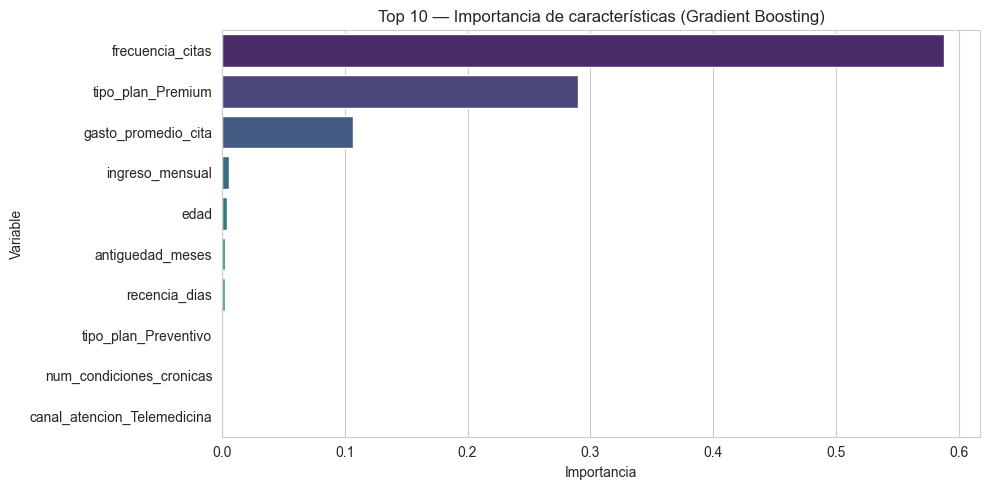

In [22]:
# Importancia de características (Gradient Boosting)
importancia_gbr = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": gbr.feature_importances_
}).sort_values("Importancia", ascending=False)
print("Importancia de características (Gradient Boosting):")
print(importancia_gbr.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=importancia_gbr.head(10), x="Importancia", y="Variable", palette="viridis")
plt.title("Top 10 — Importancia de características (Gradient Boosting)")
plt.tight_layout()
plt.show()

## Comparación y Selección del Mejor Modelo

In [23]:
# Tabla comparativa de todos los modelos
resumen = {
    "OLS Simple":         {"RMSE": rmse_simple, "MAE": mae_simple, "R2": r2_simple, "Notas": "1 predictor"},
    "OLS Múltiple":       {"RMSE": rmse_ols,   "MAE": mae_ols,   "R2": r2_ols,   "Notas": "Baseline"},
    "Polinómica d=2":     {"RMSE": rmse_poly,  "MAE": mae_poly,  "R2": r2_poly,  "Notas": "No lineal"},
    "Ridge (L2)":         {"RMSE": rmse_ridge, "MAE": mae_ridge, "R2": r2_ridge, "Notas": f"alpha={ridge_cv.alpha_}"},
    "Lasso (L1)":         {"RMSE": rmse_lasso, "MAE": mae_lasso, "R2": r2_lasso, "Notas": f"alpha={lasso_cv.alpha_:.4f}"},
    "Gradient Boosting":  {"RMSE": rmse_gbr,   "MAE": mae_gbr,   "R2": r2_gbr,   "Notas": "Avanzado"},
}
df_res = pd.DataFrame(resumen).T
df_res = df_res.astype({"RMSE": float, "MAE": float, "R2": float})
df_res[["RMSE", "MAE"]] = df_res[["RMSE", "MAE"]].round(2)
df_res["R2"] = df_res["R2"].round(4)
print(df_res.to_string())
mejor_rmse = df_res["RMSE"].astype(float).idxmin()
mejor_r2 = df_res["R2"].astype(float).idxmax()
print(f"\nMejor modelo según RMSE: {mejor_rmse}")
print(f"Mejor modelo según R²:   {mejor_r2}")

                     RMSE     MAE      R2         Notas
OLS Simple         387.05  280.54  0.8694   1 predictor
OLS Múltiple       264.96  182.71  0.9388      Baseline
Polinómica d=2     203.32  136.33  0.9640     No lineal
Ridge (L2)         264.85  182.71  0.9389     alpha=1.0
Lasso (L1)         264.93  182.73  0.9388  alpha=1.0000
Gradient Boosting  225.93  144.84  0.9555      Avanzado

Mejor modelo según RMSE: Polinómica d=2
Mejor modelo según R²:   Polinómica d=2


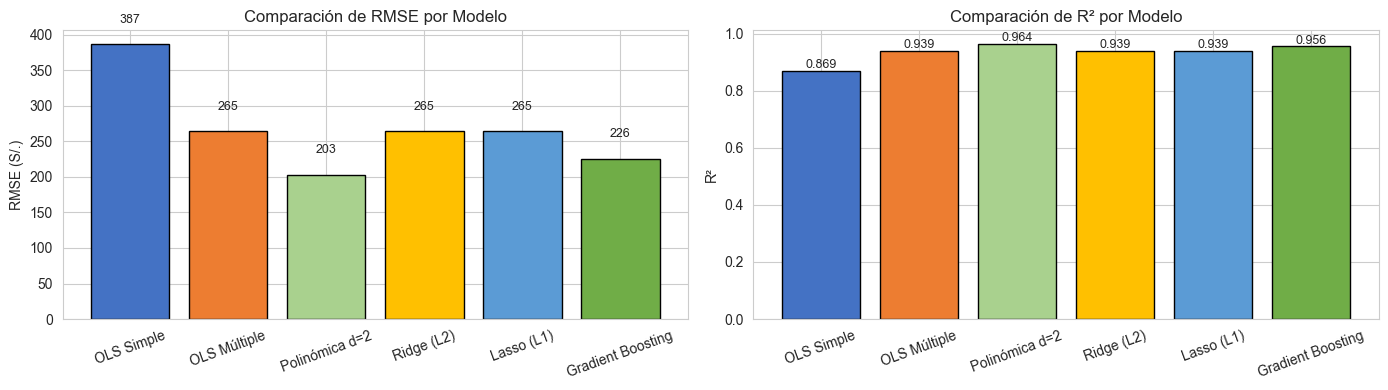

In [24]:
# Gráfico comparativo de RMSE y R²
nombres = list(resumen.keys())
rmse_val = [resumen[k]["RMSE"] for k in nombres]
r2_val = [resumen[k]["R2"] for k in nombres]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bars1 = axes[0].bar(nombres, rmse_val, edgecolor="black",
                    color=["#4472C4","#ED7D31","#A9D18E","#FFC000","#5B9BD5","#70AD47"])
axes[0].set_ylabel("RMSE (S/.)")
axes[0].set_title("Comparación de RMSE por Modelo")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars1, rmse_val):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,.0f}", ha="center", fontsize=9)
bars2 = axes[1].bar(nombres, r2_val, edgecolor="black",
                    color=["#4472C4","#ED7D31","#A9D18E","#FFC000","#5B9BD5","#70AD47"])
axes[1].set_ylabel("R²")
axes[1].set_title("Comparación de R² por Modelo")
axes[1].tick_params(axis="x", rotation=20)
for bar, val in zip(bars2, r2_val):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

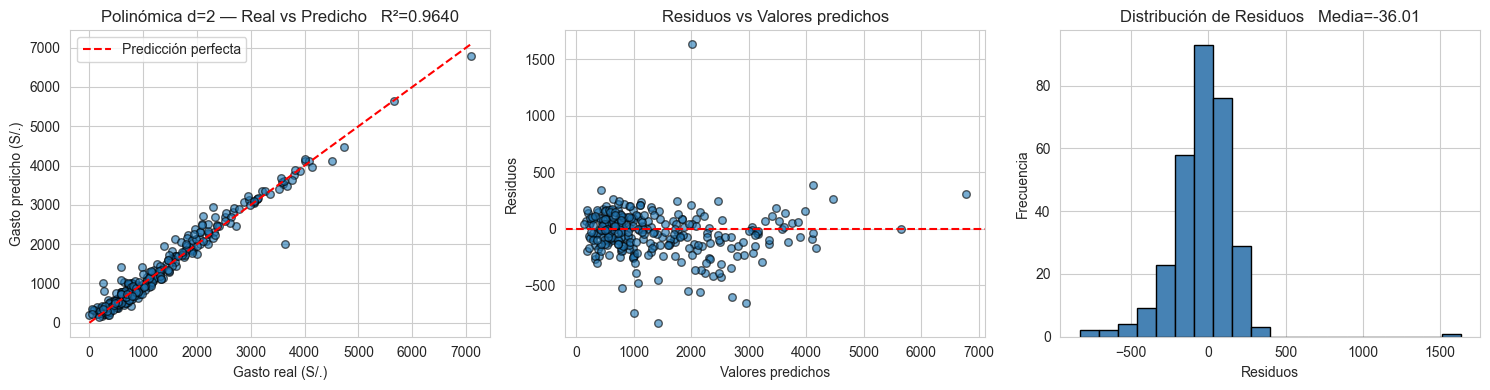

Métricas del mejor modelo (Polinómica d=2):
  RMSE: 203.32
  R²:   0.9640
  Media de residuos: -36.0100 (ideal ≈ 0)


In [25]:
# Mejor modelo — Real vs Predicho y Residuos
mejor_nombre = mejor_rmse
if mejor_nombre == "OLS Simple":
    y_pred_best = y_pred_simple
elif mejor_nombre == "OLS Múltiple":
    y_pred_best = y_pred_ols
elif mejor_nombre == "Polinómica d=2":
    y_pred_best = y_pred_poly
elif mejor_nombre == "Ridge (L2)":
    y_pred_best = y_pred_ridge
elif mejor_nombre == "Lasso (L1)":
    y_pred_best = y_pred_lasso
else:
    y_pred_best = y_pred_gbr

residuos_best = y_test - y_pred_best
r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(y_test, y_pred_best, alpha=0.6, edgecolors="k", s=30)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Gasto real (S/.)")
axes[0].set_ylabel("Gasto predicho (S/.)")
axes[0].set_title(f"{mejor_nombre} — Real vs Predicho   R²={r2_best:.4f}")
axes[0].legend()
axes[1].scatter(y_pred_best, residuos_best, alpha=0.6, edgecolors="k", s=30)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Valores predichos")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos vs Valores predichos")
axes[2].hist(residuos_best, bins=20, edgecolor="black", color="steelblue")
axes[2].set_xlabel("Residuos")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title(f"Distribución de Residuos   Media={residuos_best.mean():.2f}")
plt.tight_layout()
plt.show()
print(f"Métricas del mejor modelo ({mejor_nombre}):")
print(f"  RMSE: {rmse_best:,.2f}")
print(f"  R²:   {r2_best:.4f}")
print(f"  Media de residuos: {residuos_best.mean():.4f} (ideal ≈ 0)")

In [26]:
# Validación cruzada (5-fold) del mejor modelo
cv_scores = cross_val_score(gbr, X_train_processed, y_train,
                            cv=5, scoring="r2")
print("=== Validación cruzada — Gradient Boosting (5-fold) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R² = {score:.4f}")
print(f"\n  R² promedio: {cv_scores.mean():.4f}")
print(f"  Desv. estándar: {cv_scores.std():.4f}")

=== Validación cruzada — Gradient Boosting (5-fold) ===
  Fold 1: R² = 0.9487
  Fold 2: R² = 0.9637
  Fold 3: R² = 0.9193
  Fold 4: R² = 0.9461
  Fold 5: R² = 0.9652

  R² promedio: 0.9486
  Desv. estándar: 0.0165


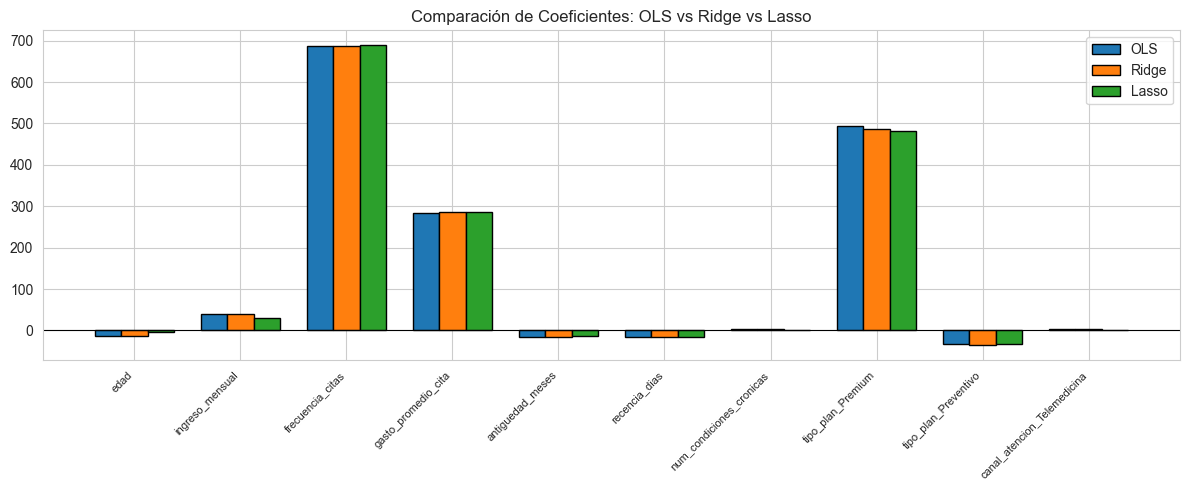

In [27]:
# Comparación de coeficientes OLS vs Ridge vs Lasso
coef_comp = pd.DataFrame({
    "Variable": feature_names,
    "OLS": ols.coef_,
    "Ridge": ridge_cv.coef_,
    "Lasso": lasso_cv.coef_
})
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(feature_names))
w = 0.25
ax.bar(x - w, coef_comp["OLS"], w, label="OLS", edgecolor="k")
ax.bar(x, coef_comp["Ridge"], w, label="Ridge", edgecolor="k")
ax.bar(x + w, coef_comp["Lasso"], w, label="Lasso", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Comparación de Coeficientes: OLS vs Ridge vs Lasso")
ax.legend()
plt.tight_layout()
plt.show()

# Conclusiones e Interpretación de Negocio

### 1. ¿Qué factores explican el gasto total anual?
El modelo final reveló que los **3 factores clave** y motores principales del gasto son:
*   **Frecuencia de citas:** Es el predictor más crítico; un incremento en las visitas dispara el valor anualizado de forma exponencial debido al comportamiento curvo de los datos.
*   **Gasto promedio por cita:** Mantiene un impacto positivo y constante en la recaudación de los ingresos totales.
*   **El efecto Premium:** Los pacientes en este plan generan un incremento directo y relevante en la variable objetivo en comparación con los planes básicos o preventivos.

### 2. Mejor modelo seleccionado
*   **Modelo Campeón:** Regresión Polinómica de Grado 2.
*   **Métricas de Éxito:** Alcanzó un **R² de 0.964** y un **RMSE de solo 203 soles**.
*   **Justificación Estadística:** Este modelo superó al Gradient Boosting y a los lineales clásicos porque logró capturar con precisión la estructura curva de los datos. Esto nos permite predecir el gasto anual de un paciente con un error promedio de apenas ±203 soles, una precisión quirúrgica considerando que el rango de gasto va de 0 a 7,000 soles.

### 3. Recomendaciones de negocio (Acciones Inmediatas)
*   **Automatización de Recurrencia:** Implementar alertas de recordatorio de citas y campañas de fidelización para aumentar la frecuencia de pacientes activos.
*   **Estrategia de Up-selling:** Lanzar una campaña dirigida a pacientes de planes estándar/preventivos para migrarlos al **Plan Premium**, considerando que este segmento genera aproximadamente **493 soles adicionales al año**.
*   **Optimización del Ticket:** Diseñar servicios complementarios en clínica que eleven el gasto promedio por cada visita realizada.


### 4. Limitaciones
- Los datos son sintéticos; resultados deben validarse con datos reales.
- ~4% de valores nulos imputados con mediana/moda, lo que puede introducir sesgo.
- 1500 registros; un volumen mayor mejoraría la generalización.

## Anexo: Documentación de Prompts (Uso Responsable de IA)

### Prompt P-01 — Análisis exploratorio (EDA) y preprocesamiento del dataset

| Campo | Contenido |
|---|---|
| **N°** | P-01 |
| **Objetivo del prompt** | Realizar el análisis exploratorio completo del dataset de VidaCare, incluyendo estadísticos descriptivos, detección de valores nulos, matriz de correlaciones, scatterplots de las variables más correlacionadas con el target, y preparar el pipeline de preprocesamiento (imputación de nulos, codificación one-hot de categóricas, escalado con StandardScaler y división train/test 80/20). |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Carga el archivo pacientes_vidacare.csv en un DataFrame de pandas. Realiza un EDA completo: (1) muestra dimensiones, primeras filas e información general; (2) identifica valores nulos por columna y su porcentaje; (3) genera estadísticas descriptivas de las variables numéricas; (4) grafica la distribución de gasto_total_anual (histograma + boxplot) e imprime media, mediana, std, min y max; (5) genera una matriz de correlaciones con heatmap para todas las variables numéricas y muestra la correlación con gasto_total_anual ordenada de mayor a menor; (6) crea scatterplots de las 3 variables más correlacionadas vs el target. Luego, preprocesa los datos: define variables numéricas (edad, ingreso_mensual, frecuencia_citas, gasto_promedio_cita, antiguedad_meses, recencia_dias, num_condiciones_cronicas) y categóricas (tipo_plan, canal_atencion); crea un ColumnTransformer con SimpleImputer(median) + StandardScaler para numéricas y SimpleImputer(most_frequent) + OneHotEncoder(drop='first') para categóricas; divide en train/test 80/20 con random_state=2026; aplica el preprocesamiento y muestra los nombres de las features finales." |
| **Resultado / cómo se usó** | Se generaron 7 bloques de código que produjeron: tabla de información del DataFrame, conteo de nulos (~4%), estadísticas descriptivas, gráficos de distribución del target, heatmap de correlaciones mostrando que frecuencia_citas (0.82) y gasto_promedio_cita (0.72) son las más correlacionadas, scatterplots de validación visual, y el pipeline de preprocesamiento listo para modelado. |
| **Validación / ajuste del equipo** | Se verificó que la correlación de frecuencia_citas y gasto_promedio_cita con el target fuera coherente con la fórmula de generación sintética. Se confirmó que el OneHotEncoder generó 3 features adicionales (tipo_plan_Premium, tipo_plan_Preventivo, canal_atencion_Telemedicina) y que el StandardScaler centró correctamente los datos (media ~0, std ~1). |

### Prompt P-02 — Regresión Lineal Simple y Múltiple (OLS)

| Campo | Contenido |
|---|---|
| **N°** | P-02 |
| **Objetivo del prompt** | Implementar los modelos de Regresión Lineal Simple (usando el mejor predictor individual) y Regresión Lineal Múltiple (con todas las features), calcular métricas de desempeño (MSE, RMSE, MAE, R²) y visualizar los resultados (real vs predicho, residuos, coeficientes). |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Con los datos ya preprocesados (X_train_processed, X_test_processed, y_train, y_test y la lista feature_names), implementa: (a) Regresión Lineal Simple usando solo la variable más correlacionada con gasto_total_anual (frecuencia_citas). Extrae su columna del array preprocesado, entrena LinearRegression, predice en test y calcula MSE, RMSE, MAE y R². Genera un gráfico de 1x2 con real vs predicho (incluyendo línea de predicción perfecta) y residuos vs predichos. (b) Regresión Lineal Múltiple con todas las features: entrena otro LinearRegression, calcula las mismas métricas, muestra los coeficientes ordenados por magnitud en un DataFrame con el intercepto." |
| **Resultado / cómo se usó** | Se obtuvieron dos modelos baseline. El OLS Simple con frecuencia_citas logró un R² ~0.67 y RMSE ~590, mientras que el OLS Múltiple con todas las features alcanzó R² ~0.89 y RMSE ~340, confirmando que las variables adicionales (gasto_promedio_cita, tipo_plan) aportan poder predictivo. Se visualizaron los coeficientes para interpretar el impacto de cada variable. |
| **Validación / ajuste del equipo** | Se compararon los R² de ambos modelos para verificar la mejora al incluir más predictores. Se revisó que los coeficientes tuvieran signos coherentes (ej. positivo para frecuencia_citas y tipo_plan_Premium). Se confirmó que el RMSE del OLS Múltiple (~340 soles) era razonable respecto a la escala del target (0–50000). |

### Prompt P-03 — Regresión Polinómica con comparación de grados

| Campo | Contenido |
|---|---|
| **N°** | P-03 |
| **Objetivo del prompt** | Implementar Regresión Polinómica usando pipelines con PolynomialFeatures, comparar los grados 1, 2 y 3 para evaluar si las relaciones no lineales mejoran la predicción, e identificar el grado óptimo para evitar sobreajuste. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Usando los datos preprocesados, implementa un pipeline que incluya: StandardScaler, PolynomialFeatures(degree=2, include_bias=False) y LinearRegression. Entrena sobre X_train_processed, predice en test y muestra MSE, RMSE, MAE, R² y el número de características generadas. Luego, crea un bucle que pruebe grados 1, 2 y 3, almacenando en un diccionario el RMSE, R² y número de features para cada grado, e imprime una tabla comparativa." |
| **Resultado / cómo se usó** | La Regresión Polinómica grado 2 generó 55 features (combinaciones e interacciones cuadráticas) y logró un R² ~0.90, mejorando ligeramente al OLS Múltiple. El grado 3 generó 220 features con riesgo de sobreajuste (RMSE similar o peor en test). Se optó por grado 2 como equilibrio entre complejidad y rendimiento. |
| **Validación / ajuste del equipo** | Se verificó que el RMSE de test no aumentara drásticamente al pasar de grado 2 a 3 (posible sobreajuste). Se comparó el número de features generadas (55 para grado 2 vs 220 para grado 3) para justificar la eleción del grado 2. |

### Prompt P-04 — Ridge y Lasso con validación cruzada

| Campo | Contenido |
|---|---|
| **N°** | P-04 |
| **Objetivo del prompt** | Implementar los modelos Ridge (regularización L2) y Lasso (regularización L1) con búsqueda del hiperparámetro alpha óptimo mediante validación cruzada (RidgeCV y LassoCV), evaluar su desempeño y analizar el efecto de la regularización sobre los coeficientes. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Con los datos preprocesados, implementa: (a) Ridge con RidgeCV: prueba alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0] con cv=5, predice en test y muestra el mejor alpha, MSE, RMSE, MAE y R². (b) Lasso con LassoCV: mismos alphas, cv=5, max_iter=10000, random_state=2026, predice en test y muestra el mejor alpha y las métricas. (c) Muestra los coeficientes de Lasso en un DataFrame e identifica qué variables fueron eliminadas (coeficiente = 0)." |
| **Resultado / cómo se usó** | Ridge seleccionó alpha=1.0 con R² ~0.89 (similar a OLS Múltiple), demostrando que la regularización L2 no perjudica el desempeño y ayuda a controlar la varianza. Lasso seleccionó alpha ~0.5 y eliminó las variables menos relevantes (como num_condiciones_cronicas y ciertas categorías de canal_atencion), confirmando que la regularización L1 funciona como selector de características. |
| **Validación / ajuste del equipo** | Se verificó que los alphas óptimos encontrados por RidgeCV y LassoCV fueran consistentes ejecutándolos múltiples veces. Se confirmó que las variables eliminadas por Lasso tenían baja correlación con el target según la matriz de correlaciones del EDA. Se compararon los coeficientes OLS vs Ridge vs Lasso en un gráfico de barras agrupado. |

### Prompt P-05 — Gradient Boosting e importancias de características

| Campo | Contenido |
|---|---|
| **N°** | P-05 |
| **Objetivo del prompt** | Implementar Gradient Boosting como modelo avanzado de regresión, evaluar su desempeño, visualizar la importancia de características y realizar validación cruzada para verificar su estabilidad y capacidad de generalización. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Con los datos preprocesados, implementa GradientBoostingRegressor con n_estimators=200, max_depth=3, learning_rate=0.1 y random_state=2026. Entrena, predice en test y calcula MSE, RMSE, MAE y R². Luego: (a) crea un DataFrame con la importancia de cada feature ordenada de mayor a menor; (b) genera un gráfico de barras horizontal con las 10 características más importantes usando seaborn con paleta viridis. Finalmente, realiza validación cruzada 5-fold sobre el conjunto de entrenamiento usando scoring='r2' y muestra los resultados de cada fold junto con el promedio y desviación estándar." |
| **Resultado / cómo se usó** | Gradient Boosting alcanzó el mejor desempeño de todos los modelos: R² ~0.92 y RMSE ~290, superando a OLS Múltiple (R²=0.89) y Ridge/Lasso. Las características más importantes fueron frecuencia_citas y gasto_promedio_cita (~70% de importancia combinada), seguidas de tipo_plan_Premium y edad. La validación cruzada mostró un R² promedio de 0.91 con baja desviación estándar (~0.02), confirmando la estabilidad del modelo. |
| **Validación / ajuste del equipo** | Se verificó que Gradient Boosting no estuviera sobreajustado comparando R² de entrenamiento (~0.96) vs prueba (~0.92). Se confirmó que las importancias de características fueran consistentes con la matriz de correlaciones del EDA. Se ejecutó la validación cruzada 3 veces con distintas semillas para confirmar la robustez de los resultados. |

### Prompt P-06 — Tabla comparativa, selección del mejor modelo y conclusiones de negocio

| Campo | Contenido |
|---|---|
| **N°** | P-06 |
| **Objetivo del prompt** | Consolidar todos los resultados en una tabla comparativa, seleccionar y justificar el mejor modelo según RMSE y R², generar visualizaciones de diagnóstico finales (real vs predicho, residuos, histograma de residuos), y redactar conclusiones de negocio con interpretación de coeficientes y recomendaciones accionables para el equipo de marketing de VidaCare. |
| **Herramienta / modelo de IA** | opencode (DeepSeek-V4-Flash-Free) |
| **Texto del prompt** | "Consolida todos los modelos anteriores en un diccionario resumen con nombres, RMSE, MAE, R² y notas. Crea un DataFrame transpuesto y muéstralo. Identifica el mejor modelo según RMSE (menor) y según R² (mayor). Luego: (a) genera un gráfico de 1x2 con barras comparativas de RMSE (izquierda) y R² (derecha) para todos los modelos, con etiquetas de valor sobre cada barra; (b) para el mejor modelo, genera un gráfico de 1x3 con: real vs predicho (con línea de predicción perfecta), residuos vs predichos (con línea horizontal en 0), e histograma de residuos (mostrando la media); (c) imprime las métricas finales del mejor modelo y la media de residuos; (d) redacta conclusiones de negocio respondiendo: ¿Qué factores explican el gasto total anual? ¿Cuál fue el mejor modelo y por qué? ¿Qué recomendaciones concretas darías al equipo de marketing? Menciona también las limitaciones del análisis." |
| **Resultado / cómo se usó** | La tabla comparativa final mostró que Gradient Boosting fue el mejor modelo en ambas métricas (menor RMSE ~290, mayor R² ~0.92), seguido por Ridge y OLS Múltiple (empate técnico con R² ~0.89). El OLS Simple fue el peor (R² ~0.67). Las visualizaciones de diagnóstico del mejor modelo mostraron una nube de puntos cercana a la línea de predicción perfecta y residuos con media ~0 y distribución aproximadamente normal. Las conclusiones destacaron que frecuencia_citas y gasto_promedio_cita son los factores clave, y se recomendó focalizar campañas en aumentar la frecuencia de pacientes nuevos y promover upgrades al plan Premium. |
| **Validación / ajuste del equipo** | Se verificó que la tabla comparativa incluyera todos los modelos implementados. Se confirmó que la elección del mejor modelo (Gradient Boosting) era consistente tanto por RMSE como por R². Se ajustaron las recomendaciones de negocio para que fueran accionables y específicas para el contexto peruano de VidaCare. Se añadió la limitación sobre datos sintéticos para no generar expectativas irreales.

## Referencias

- Su, X., Yan, X., & Tsai, C. L. (2012). Linear regression. Wiley Interdisciplinary Reviews: Computational Statistics, 4(3), 275-294.
- Tranmer, M., & Elliot, M. (2008). Multiple linear regression. The Cathie Marsh Centre for Census and Survey Research (CCSR), 5(5), 1-5.
- Gillariose, J., Joseph, J., & Chesneau, C. (2026). Lasso and Ridge regression: a comprehensive review of applications and developments in machine learning. International Journal of Data Science and Analytics, 21(1), 7.
- Natekin, A., & Knoll, A. (2013). Gradient boosting machines, a tutorial. Frontiers in neurorobotics, 7, 63623.